<a href="https://colab.research.google.com/github/anagaglory/stock-regression-analysis/blob/main/stock_price_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("Stock Dataset.csv")

In [ ]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943.0
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957.0
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711.0
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061.0
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43224 entries, 0 to 43223
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   symbol  43224 non-null  object 
 1   date    43224 non-null  object 
 2   open    43224 non-null  float64
 3   high    43224 non-null  float64
 4   low     43224 non-null  float64
 5   close   43224 non-null  float64
 6   volume  43223 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.3+ MB


In [ ]:
print(df.columns)

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [ ]:
X = df[['open']]
y = df['close']

In [ ]:
df.isnull().sum()

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
volume,1


In [ ]:
df = df.dropna()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(df[['open', 'close']].isnull().sum())

open     0
close    0
dtype: int64


In [ ]:
print(df[['open', 'close']].dtypes)

open     float64
close    float64
dtype: object


In [ ]:
df = df.dropna(subset=['open', 'close'])

In [ ]:
X = df[['open']]
y = df['close']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())

       Actual   Predicted
465     78.91   78.663971
1278    53.15   53.762058
15320   78.18   78.574145
14384   40.45   39.789041
29587  119.00  119.016049


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 2.1360422403914767


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9996648468533641


In [ ]:
print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

Intercept: 0.09569142138211362
Coefficient: 0.9980726596035505


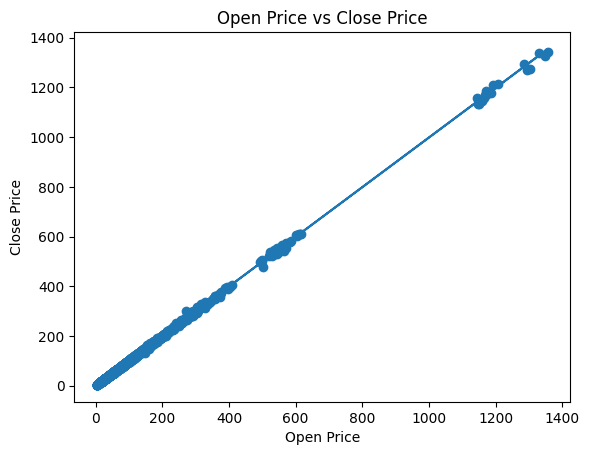

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Open Price")

plt.ylabel("Close Price")

plt.title("Open Price vs Close Price")

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 2.1360422403914767
R²: 0.9996648468533641


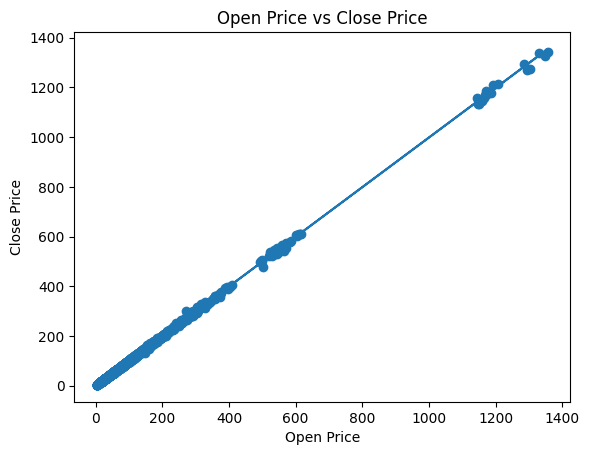

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Open Price vs Close Price")

plt.savefig("stock_regression_plot.png", dpi=300, bbox_inches="tight")

plt.show()